# Full-Text Test Run: Coding the Integration Ladder, and Checking the Evidence

### Applying the Stage 3 deep coding scheme to the open-access full texts the abstract stage carried forward, once per model, with three providers

**Stijn Van Severen · Christopher Eccleston · Annick De Paepe · Maya Braun · Julie Dendauw · Jose Luis Socorro Cumplido · Geert Crombez**
Ghent University · OSF registration [10.17605/OSF.IO/T4FAM](https://doi.org/10.17605/OSF.IO/T4FAM)

---

This notebook is the **second half** of the chain that
[`01_abstractlevel_testrun.ipynb`](01_abstractlevel_testrun.ipynb) starts. That notebook coded
100 PubMed abstracts with three models and produced a consensus candidate set. This one
retrieves the open-access full texts of those candidates and applies the **Stage 3 deep coding
scheme** to each of them with the same three models.

The two stages differ in purpose, not only in depth:

| | Abstract level (scheme 2) | Full text (scheme 3) |
| --- | --- | --- |
| Reads | title and abstract | the whole article |
| Mainly does | routing and relevance filtering | graded measurement of coverage and integration |
| Core output | a provisional signal | a graded ladder with a quoted passage behind every rung |
| Answers | which records are worth reading | does a biopsychosocially labelled review actually integrate the three domains, and how |

> **This is a test run of the instrument, not a finding about the literature.** Three cheap
> models on 47 open-access articles cannot settle what the biopsychosocial literature does.
> What the run can establish is whether the coding scheme is specified tightly enough that
> independent coders converge, and whether the evidence those coders return is real.

**What this notebook does**

1. Sets out the scheme: three coverage ladders, four integration ladders, and six evidence lists.
2. Follows the corpus funnel from 100 abstracts to the coded full texts, accounting for every drop.
3. Shows exactly what one paper's instruction set and coded output look like.
4. Applies the scheme with every model, one paper per request.
5. Checks integrity first: is the grid complete, are the quotes real, is a graded ladder backed by a passage.
6. Quantifies reliability, including an adjacent-agreement rate built for ordered ladders.
7. Renders four multi-panel figures.
8. Compares the coded typology against the typology the rules derive from coverage and integration.
9. Reports the consensus picture, the cost, and what this says to the expert evaluation.

In [1]:
# --- Setup -------------------------------------------------------------------
import json
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Make the package importable even without an editable install.
ROOT = Path.cwd()
while not (ROOT / "src" / "03_pipeline").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src" / "03_pipeline"))

from bps_review.fulltext.analysis.integrity import build_integrity, label_catalog
from bps_review.fulltext.analysis.reliability import build_reliability
from bps_review.fulltext.coding.condense import build_coding_text
from bps_review.fulltext.coding.prompt import LADDERS, build_prompt, prompt_overview
from bps_review.fulltext.coding.runner import load_items, load_or_run, run_fulltext_testrun
from bps_review.fulltext.config import (
    COVERAGE_FIELDS,
    FIELD_LABELS,
    FULLTEXT_MODELS,
    INTEGRATION_FIELDS,
    LIST_FIELDS,
    PRESENCE_FIELDS,
    codings_dir,
    corpus_manifest_json,
    corpus_selection_log_csv,
    figures_dir,
    reliability_dir,
)
from bps_review.fulltext.corpus.pmc import load_corpus, load_corpus_records
from bps_review.fulltext.pipeline import ensure_corpus
from bps_review.fulltext.report import write_fulltext_summary
from bps_review.fulltext.visualization.figures import build_figures

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 175)
print(f"Repository root: {ROOT}")
print("Environment ready.")

Repository root: /Users/stijnvanseveren/PROJECTS/summer_2026/CROMBEZ_MAP/05_BPS_Review_Study
Environment ready.


## 1. What the scheme measures

The review's central claim is that biopsychosocial language is widespread while substantive
three-domain integration is not. The scheme is built to test that claim, so its most
consequential fields are **ladders** rather than labels: each one asks how deep something goes,
not whether it is there.

Three coverage ladders, one per domain. Four integration ladders: three pairwise and one
triadic. Every rung has an operational rule that separates it from the rung below.

In [2]:
for name, rungs in LADDERS.items():
    print(f"### {name.replace('_', ' ')}")
    for value, rule in rungs.items():
        print(f"  {value:14s} {rule}")
    print()

### domain coverage
  elaborated     The domain is developed as a substantive analytic thread: several distinct constructs or mechanisms discussed, weighed, or synthesized rather than named.
  mentioned      The domain is explicitly present with at least one named construct, but is not developed into a sustained thread.
  minimal        The domain appears only as an umbrella label or a single incidental reference, with no concrete construct attached.
  absent         The domain is not represented in the substantive content, even if a global BPS label is used elsewhere.

### pairwise integration
  mechanistic    A pathway or process by which one domain acts on the other is specified: a named mediator, moderator, or physiological or behavioural route.
  directional    A directional or causal influence is asserted (X predicts, increases, worsens Y) but no pathway is given.
  descriptive    The two domains are linked as associated or correlated, without direction or mechanism.
  mentioned 

In [3]:
overview = prompt_overview()
print(f"Coded fields in the instruction set : {overview['n_coded_fields']}")
print(f"Fields with a closed value list     : {overview['n_controlled_fields']}")
print(f"Structured extraction lists         : {overview['n_extraction_lists']}")
print(f"Fields inside those list items      : {overview['n_item_level_fields']}")
print(f"Maximum quote length                : {overview['max_quote_words']} words")
print()
print("Item caps (ceilings, never targets):")
for name, cap in overview["item_caps"].items():
    print(f"  {name:26s} {cap}")

Coded fields in the instruction set : 22
Fields with a closed value list     : 12
Structured extraction lists         : 6
Fields inside those list items      : 25
Maximum quote length                : 60 words

Item caps (ceilings, never targets):
  integration_claims         10
  domain_evidence            6
  psychological_concepts     14
  theoretical_frameworks     6
  conceptual_problems        8
  key_quotes                 6


### What is judged and what is derived

The same discipline as at the abstract level, and for the same reason: a verdict a coder is
asked for is a judgement that can drift; a verdict computed from coded content is a rule that
can be audited.

- **Judged**: the coverage and integration ladders, balance, typology, whether concepts are
  defined, and every extraction list.
- **Derived**: eligibility, conceptual yield, synthesis priority, the integration index, the
  binary presence flags, and a second typology computed from coverage and integration by rule.
  Derived columns are recomputed whenever a cached run is loaded, so a change in the rules takes
  effect without re-coding anything.

In [4]:
presence = pd.DataFrame({"Derived presence flag": [FIELD_LABELS[f] for f in PRESENCE_FIELDS],
                         "Column": PRESENCE_FIELDS})
presence

,Derived presence flag,Column
0,Integration evidence present,present_integration_evidence
1,Triadic claim present,present_triadic_claim
2,Psychological concepts present,present_psychological_concepts
3,Defined concepts present,present_defined_concepts
4,Frameworks present,present_theoretical_frameworks
5,Conceptual problems present,present_conceptual_problems
6,Biological evidence present,present_domain_evidence_bio
7,Psychological evidence present,present_domain_evidence_psych
8,Social evidence present,present_domain_evidence_social


## 2. The corpus funnel

The full-text stage does not run its own search. It reads the candidate set the abstract stage
produced and tries to retrieve each candidate's full text from PubMed Central's open-access
subset, through the same NCBI E-utilities the review already uses for MEDLINE.

Every candidate that drops out is logged with the reason, so the funnel from 100 abstracts to
the coded papers is fully accounted for. Most of the loss is simply that a paper is not open
access, which is a property of the literature rather than of the pipeline.

In [5]:
corpus = ensure_corpus()          # cached; pass force=True to retrieve again
manifest = json.loads(corpus_manifest_json().read_text())

print(f"Abstract-level candidates carried forward : {manifest['n_candidates']}")
print(f"Of those, with a PubMed Central id        : {manifest['n_with_pmcid']}")
print(f"Full texts retrieved and parsed           : {manifest['n_retrieved']}")
print(f"Dropped                                   : {manifest['n_dropped']}")
print()
for reason, count in manifest["drop_reasons"].items():
    print(f"  {count:3d}  {reason}")
print()
print(f"Median body length: {manifest['median_body_chars']:,.0f} characters "
      f"(longest {manifest['max_body_chars']:,})")

Abstract-level candidates carried forward : 88
Of those, with a PubMed Central id        : 53
Full texts retrieved and parsed           : 47
Dropped                                   : 41

   35  no PubMed Central record (not open access)
    6  retrieved body too short (0 chars)

Median body length: 41,633 characters (longest 201,188)


In [6]:
log = pd.read_csv(corpus_selection_log_csv()).fillna("")
print(log["status"].value_counts().to_string())
corpus[["record_id", "abstract_record_id", "year", "journal", "n_sections", "body_chars", "title"]].head(8)

status
retrieved    47
dropped      41


,record_id,abstract_record_id,year,journal,n_sections,body_chars,title
0,F001_42080121,A003_42080121,2026,Frontiers in Aging Neuroscience,35,69892,Myofascial pain in older adults: a geroscience-informed framework integrating precision geriatri...
1,F002_41976799,A004_41976799,2026,Journal of Clinical Medicine,20,36845,Biopsychosocial Predictors of Pain Persistence and Pain Chronification in Temporomandibular Diso...
2,F003_41868689,A007_41868689,2026,Pain Reports,27,58461,Acceptance of pain neuroscience education in chronic musculoskeletal pain conditions: qualitativ...
3,F004_41492309,A013_41492309,2026,Osteoarthritis and Cartilage Open,24,29048,Biopsychosocial predictive factors for developing chronic postsurgical pain after hip replacemen...
4,F005_41058307,A019_41058307,2025,Journal of Oral Rehabilitation,18,31750,Self‐Management Therapies for Temporomandibular Disorders—Evidence From Systematic Reviews
5,F006_41676335,A023_41676335,2026,Frontiers in Pain Research,9,29179,Chronic pain in transgender and gender-diverse youth: a biopsychosocial perspective
6,F007_41436105,A027_41436105,2025,Journal of Oral & Facial Pain and Headache,10,132903,Applicability of the theory of pain-sensorimotor interactions to orofacial pain and sensorimotor...
7,F008_41409397,A029_41409397,2025,Journal of Pain Research,49,55062,Flow-Induced Analgesia: A Conceptual Review of Biopsychosocial and Neurobiological Mechanisms of...


**How much of a paper reaches the model.** Every model here advertises at least a 131k-token
context window, so the binding constraint is cost, not context. The reading budget is 60,000
characters, roughly 15k tokens per paper. A paper that exceeds it is not truncated: the
condenser scores every paragraph on how much biopsychosocial content it carries, protects the
opening paragraphs of the introduction and the discussion, keeps the highest-scoring paragraphs
until the budget is spent, and marks every gap with an explicit omission marker so the model can
see that the text is partial.

In [7]:
records = load_corpus_records()
stats = []
for record in records:
    _, info = build_coding_text(record)
    stats.append(info)
stats_df = pd.DataFrame(stats)
print(f"Papers sent whole      : {int((~stats_df['reduced']).sum())} of {len(stats_df)}")
print(f"Papers condensed       : {int(stats_df['reduced'].sum())}")
if stats_df['reduced'].any():
    kept = stats_df.loc[stats_df['reduced'], 'kept_share']
    print(f"Of the condensed ones, paragraphs kept: {kept.min():.0%} to {kept.max():.0%}")
print(f"Mean characters sent   : {stats_df['coding_text_chars'].mean():,.0f}")

Papers sent whole      : 40 of 47
Papers condensed       : 7
Of the condensed ones, paragraphs kept: 23% to 99%
Mean characters sent   : 44,554


## 3. What one coder actually receives

The instruction set is assembled from the schema and the ladders rather than written out by
hand, so it can never drift from what the validator accepts or from what the dossier shows the
experts. Below is the head of the prompt for one paper, followed by the coding principles that
govern the whole run.

In [8]:
example_record = records[0]
prompt = build_prompt(example_record, "TITLE: ...")
print(f"Prompt length for one paper: {len(build_prompt(example_record, build_coding_text(example_record)[0])):,} characters")
print()
print(prompt_overview()["system_prompt"])

Prompt length for one paper: 82,349 characters

You are a meticulous systematic-review coder working on how the biopsychosocial model is operationalized in chronic pain reviews. You read one full-text article at a time and return a single strict JSON object that follows the given schema exactly. You quote the article verbatim, you never invent content, you never treat the word biopsychosocial as evidence of coverage, and you prefer the lower rung of a ladder over a generous reading. You return JSON only, with no prose, no markdown, and no code fences.


In [9]:
from bps_review.fulltext.coding.prompt import CODING_PRINCIPLES

for index, principle in enumerate(CODING_PRINCIPLES, start=1):
    print(f"{index}. {principle}")
    print()

1. Code this paper only. Never import knowledge about the biopsychosocial model from the wider literature, from the models you know, or from other papers. If this paper does not say it, it is not coded.

2. The word 'biopsychosocial' is never evidence of coverage. A review can use the label in every paragraph and still score a domain as absent. Coverage is judged on substantive domain content: named constructs, mechanisms, determinants, measures, or interventions belonging to that domain.

3. Quote, do not paraphrase. Every verbatim field must contain text copied exactly from the article, with the original wording and spelling. Copy a contiguous passage. Do not stitch fragments together, do not clean the language up, and never write a quote the paper does not contain. If you cannot find a passage that carries the point, leave the verbatim field empty and say what you saw in the accompanying note instead.

4. Integration is a claim about a relation, not about co-occurrence. Two domains 

## 4. Applying the scheme

One paper is one request. Full texts are far too long to batch, and a per-paper call keeps a
failure local to a single cell of the (paper x model) grid. Papers are coded concurrently
inside a model and the three models run in parallel.

Three properties of the runner matter for whether the output can be trusted:

- **A response that is not a coding of this paper is rejected, not repaired.** The repair layer
  fixes a malformed field. A response with the wrong record id, or with almost none of the
  schema's keys, is a failed call and is retried.
- **A paper that never codes is written as an explicit failure row.** It is never filled with a
  plausible-looking coding, so gaps stay visible in the analysis.
- **Every attempt carries a hard wall-clock timeout**, because a provider that trickles bytes
  never trips the socket read timeout.

In [10]:
FORCE_RERUN = False   # True re-codes every paper with every model via the API

long_df = run_fulltext_testrun() if FORCE_RERUN else load_or_run(force=False)
items_df = load_items()

print(f"{len(long_df)} codings = {long_df['record_id'].nunique()} papers x {long_df['model_label'].nunique()} models")
print(f"{len(items_df):,} extracted items carrying a label, a quote, or both")
long_df[["record_id", "model_label", "domain_coverage_bio", "domain_coverage_psych",
         "domain_coverage_social", "integration_triadic", "bps_typology"]].head(6)

141 codings = 47 papers x 3 models
4,080 extracted items carrying a label, a quote, or both


,record_id,model_label,domain_coverage_bio,domain_coverage_psych,domain_coverage_social,integration_triadic,bps_typology
0,F001_42080121,DeepSeek-V4-Flash,elaborated,elaborated,mentioned,partial,pseudo_bps
1,F002_41976799,DeepSeek-V4-Flash,mentioned,elaborated,mentioned,partial,multifactorial
2,F003_41868689,DeepSeek-V4-Flash,mentioned,mentioned,minimal,none,pseudo_bps
3,F004_41492309,DeepSeek-V4-Flash,elaborated,elaborated,minimal,partial,multifactorial
4,F005_41058307,DeepSeek-V4-Flash,minimal,elaborated,absent,none,pseudo_bps
5,F006_41676335,DeepSeek-V4-Flash,elaborated,elaborated,elaborated,descriptive,true_integrative


### One paper, three coders

The same article, read three times. This is where the ladders become concrete.

In [11]:
example_id = sorted(long_df["record_id"].unique())[0]
paper = corpus[corpus["record_id"] == example_id].iloc[0]
print(f"{paper['record_id']}  ({paper['year']}, {paper['journal']}, {paper['body_chars']:,} characters)")
print(paper["title"])

F001_42080121  (2026, Frontiers in Aging Neuroscience, 69,892 characters)
Myofascial pain in older adults: a geroscience-informed framework integrating precision geriatrics and digital therapeutics


In [12]:
shown = (list(COVERAGE_FIELDS) + list(INTEGRATION_FIELDS)
         + ["overall_balance", "bps_typology", "concept_definitions_present",
            "n_integration_claims", "n_psychological_concepts", "n_evidence_quotes",
            "conceptual_yield", "fulltext_eligibility", "synthesis_priority"])
(long_df[long_df["record_id"] == example_id]
 .set_index("model_label")[shown].T.rename_axis("field"))

model_label,DeepSeek-V4-Flash,Nex-N2-Mini,Laguna-XS-2.1
field,,,
domain_coverage_bio,elaborated,elaborated,elaborated
domain_coverage_psych,elaborated,elaborated,elaborated
domain_coverage_social,mentioned,mentioned,mentioned
integration_bio_psych,mechanistic,mechanistic,mechanistic
integration_psych_social,mentioned,descriptive,directional
integration_bio_social,none,directional,descriptive
integration_triadic,partial,descriptive,descriptive
overall_balance,dyadic,bio-dominant,psych-dominant
bps_typology,pseudo_bps,true_integrative,multifactorial


In [13]:
# The evidence behind one model's integration judgement on this paper.
claims = json.loads(
    long_df[(long_df["record_id"] == example_id) & (long_df["model_label"] == "Nex-N2-Mini")]
    .iloc[0]["integration_claims"]
)
for claim in claims[:4]:
    print(f"[{claim['domains_linked']} / {claim['integration_level']} / {claim['section_located']}]")
    print(f"  \"{claim['claim_verbatim']}\"")
    if claim.get("mechanism_note"):
        print(f"  mechanism: {claim['mechanism_note']}")
    print()

[bio_psych / mechanistic / discussion]
  "Psychological factors, which are highly prevalent in older adults with chronic pain, act as powerful top-down modulators of this centralized pain state ( ; ). Pain catastrophizing (a negative cognitive-affective response to pain), anxiety, and depression can directly amplify the activity in these emotional brain circuits, further enhancing the perception of pain and creating a vicious, self-perpetuating cycle ( )."
  mechanism: Pain catastrophizing, anxiety, and depression are posited to amplify emotional brain circuits and central sensitization.

[bio_psych / mechanistic / discussion]
  "There is often a shift from acute nociceptive processing to circuits involved in emotion and salience, explaining why chronic pain becomes so emotionally distressing and all-consuming ( )."
  mechanism: Central pain-processing circuits are linked to emotional salience and distress.

[psych_social / descriptive / discussion]
  "The emotional suffering, or the a

## 5. Integrity first: can this output be trusted at all?

Reliability tells you whether the coders agree. It does not tell you whether they read the
paper. At full-text level that second question is the more important one, and it is answerable,
because the scheme asks for verbatim evidence and a quote can be checked against ground truth.

Three checks run before any agreement statistic.

In [14]:
integrity = build_integrity(long_df, items_df, records, write=True)
completeness = integrity["completeness"]

print(f"Expected codings : {completeness['expected_codings']}")
print(f"Actual codings   : {completeness['actual_codings']}")
print(f"Grid complete    : {completeness['grid_complete']}")
print(f"Failed codings   : {completeness['n_failed_codings']}")
print(f"Coding methods   : {completeness['coding_method_counts']}")
print()
totals = integrity["extraction_totals"]
print(f"Extracted items  : {totals['total_extracted_items']:,}")
print(f"Evidence quotes  : {totals['total_evidence_quotes']:,}")
print(f"Distinct labels  : {totals['distinct_normalized_labels']:,}")
print()
print("Items per extraction list:")
for field, count in totals["items_per_field"].items():
    print(f"  {FIELD_LABELS.get(field, field):26s} {count:,}")

Expected codings : 141
Actual codings   : 141
Grid complete    : True
Failed codings   : 0
Coding methods   : {'llm_structured': 141}

Extracted items  : 4,080
Evidence quotes  : 3,312
Distinct labels  : 771

Items per extraction list:
  Psychological concepts     1,302
  Integration claims         792
  Key quotes                 639
  Conceptual problems        469
  Theoretical frameworks     466
  Domain evidence            412


### Are the quotes real?

Every verbatim quote is looked up in the article it came from. A quote is **exact** when its
normalized form appears literally, **near** when most of its word 5-grams appear (a typo, an
expanded ligature, a dropped citation marker), and **unverified** otherwise. An unverified quote
is either a paraphrase presented as a quote or an invention, and for this scheme both are
defects. The per-model spread is a concrete selection criterion for the state-of-the-art run.

In [15]:
integrity["quote_verification_by_model"].round(4)

,model_label,n_quotes,exact_rate,near_rate,verified_rate,unverified_rate,mean_quote_words,mean_ngram_coverage
0,DeepSeek-V4-Flash,703,0.9075,0.0839,0.9915,0.0085,23.4708,0.9820
1,Nex-N2-Mini,1735,0.9746,0.0242,0.9988,0.0012,28.0098,0.9973
2,Laguna-XS-2.1,868,0.7869,0.1993,0.9862,0.0138,33.3053,0.9667


In [16]:
integrity["quote_verification_by_field"].round(4)

,extraction_field,n_quotes,verified_rate,mean_quote_words
2,integration_claims,792,0.9975,30.6174
3,key_quotes,639,0.9922,28.8529
4,psychological_concepts,538,0.9926,23.2082
5,theoretical_frameworks,466,0.9936,27.0558
0,conceptual_problems,461,0.9913,26.2082
1,domain_evidence,410,0.9951,34.4976


### Is a graded ladder backed by a passage?

This is the check that decides whether the integration numbers mean anything. For every coding
and every domain pair graded above `mentioned`, it asks whether the coder returned a quoted
claim for exactly that pair. A graded link with no passage behind it is a judgement the review
cannot audit.

In [17]:
discipline = integrity["summary"]["evidence_discipline"]
print(f"Domain links graded above 'mentioned' : {discipline['n_graded_links']}")
print(f"Backed by a quoted claim for that pair: {discipline['share_backed_by_quote']:.1%}")
print()
integrity["evidence_discipline_by_model"].round(3)

Domain links graded above 'mentioned' : 356
Backed by a quoted claim for that pair: 95.2%



,model_label,n_graded_links,share_backed_by_quote
0,DeepSeek-V4-Flash,83,1.000
1,Laguna-XS-2.1,105,0.962
2,Nex-N2-Mini,168,0.923


In [18]:
unbacked = integrity["evidence_discipline"]
unbacked = unbacked[unbacked["has_quoted_claim"] == "no"]
if len(unbacked):
    print(f"{len(unbacked)} graded links carry no matching quote. Which pairs are affected:")
    print(unbacked.groupby(["domain_pair", "integration_level"]).size().to_string())
else:
    print("Every graded link carries a matching quote.")

17 graded links carry no matching quote. Which pairs are affected:
domain_pair   integration_level
bio_psych     mechanistic          1
bio_social    descriptive          4
              directional          2
              mechanistic          3
psych_social  descriptive          1
              directional          1
triadic       descriptive          2
              partial              3


## 6. Cross-provider reliability

Three kinds of variable, kept apart because they answer different questions.

- **The ordered ladders** get kappa and alpha, plus an **adjacent-agreement rate**: the share of
  coder pairs that sat at most one rung apart. On an ordered scale that distinction matters. Two
  coders who write `mechanistic` and `directional` disagree about how much detail the paper
  gives; two who write `mechanistic` and `none` disagree about whether the paper makes a
  cross-domain claim at all. Kappa treats those as the same error.
- **The binary presence flags**, derived from the coded content, ask a question with one answer
  per paper: did this coder find material of this kind here.
- **The open lists** get set overlap, because two coders can both be right and still write
  different strings.

In [19]:
results = build_reliability(long_df, write=True)
field_rel = results["field_reliability"]
field_rel[["field_label", "group", "n_categories", "mean_pairwise_agreement",
           "adjacent_agreement", "unanimous_rate", "fleiss_kappa",
           "krippendorff_alpha", "landis_koch"]].round(3)

,field_label,group,n_categories,mean_pairwise_agreement,adjacent_agreement,unanimous_rate,fleiss_kappa,krippendorff_alpha,landis_koch
0,Biological coverage,coverage,4,0.638,0.950,0.532,0.312,0.317,Fair
1,Psychological coverage,coverage,4,0.780,0.979,0.681,0.551,0.554,Moderate
2,Social coverage,coverage,4,0.482,0.837,0.319,0.273,0.278,Fair
3,Bio-psych integration,integration,5,0.319,0.716,0.128,0.039,0.046,Slight
4,Psych-social integration,integration,5,0.262,0.645,0.064,0.062,0.069,Slight
5,Bio-social integration,integration,5,0.291,0.525,0.043,-0.006,0.001,Poor
6,Triadic integration,integration,4,0.340,0.816,0.064,0.071,0.078,Slight
7,Review track,nominal,4,0.525,NaN,0.298,0.116,0.122,Slight
8,Source type,nominal,7,0.894,NaN,0.851,0.833,0.834,Almost perfect
9,Overall balance,nominal,6,0.511,NaN,0.362,0.372,0.377,Fair


In [20]:
summary = results["summary"]
print(f"Papers                              : {summary['n_papers']}")
print(f"Codings                             : {summary['n_codings']}")
print(f"Mean Fleiss' kappa (all fields)     : {summary['mean_fleiss_kappa']:.3f}")
print(f"  categorical fields                : {summary['categorical_mean_fleiss_kappa']:.3f}")
print(f"  derived presence flags            : {summary['presence_mean_fleiss_kappa']:.3f}")
print(f"Mean observed agreement             : {summary['mean_pairwise_agreement']:.1%}")
print(f"Coverage ladders, within one rung   : {summary['coverage_mean_adjacent_agreement']:.1%}")
print(f"Integration ladders, within one rung: {summary['integration_mean_adjacent_agreement']:.1%}")
print()
most, least = summary["most_agreeing_pair"], summary["least_agreeing_pair"]
print(f"Closest pair : {most['models'][0]} and {most['models'][1]} ({most['agreement']:.1%})")
print(f"Most distant : {least['models'][0]} and {least['models'][1]} ({least['agreement']:.1%})")
print(f"Unanimous on eligibility: {summary['eligibility_unanimous_items']} of {summary['n_papers']} papers")

Papers                              : 47
Codings                             : 141
Mean Fleiss' kappa (all fields)     : 0.178
  categorical fields                : 0.217
  derived presence flags            : 0.119
Mean observed agreement             : 65.9%
Coverage ladders, within one rung   : 92.2%
Integration ladders, within one rung: 67.6%

Closest pair : DeepSeek-V4-Flash and Laguna-XS-2.1 (70.9%)
Most distant : Nex-N2-Mini and Laguna-XS-2.1 (62.1%)
Unanimous on eligibility: 38 of 47 papers


### The open extraction lists

In [21]:
results["list_overlap"].round(3)

,field,field_label,mean_pairwise_jaccard,n_comparable_pairs,distinct_labels_total,papers_with_a_shared_label,mean_items_DeepSeek-V4-Flash,mean_items_Nex-N2-Mini,mean_items_Laguna-XS-2.1
0,psychological_concepts,Psychological concepts,0.369,141,494,45,7.11,13.36,7.21
1,theoretical_frameworks,Theoretical frameworks,0.304,138,269,26,2.45,5.32,2.15
2,conceptual_problems,Conceptual problems,0.296,141,9,27,2.21,4.19,3.02


### How the models differ

Agreement says how often two coders match. It does not say which way each leans. The columns
below are the leanings, and they are what a reader should have in mind when interpreting any
single model's output.

In [22]:
results["per_model_behavior"].round(3)

,model_label,provider,include_rate,core_priority_rate,true_integrative_rate,triadic_any_rate,bio_elaborated_rate,psych_elaborated_rate,social_elaborated_rate,mean_integration_index,mean_integration_claims,mean_concepts,mean_defined_concepts,mean_frameworks,mean_extracted_items,typology_matches_derived,structured_share
0,DeepSeek-V4-Flash,DeepSeek,0.830,0.447,0.043,0.511,0.511,0.574,0.255,0.274,3.511,7.106,1.574,2.447,20.915,0.702,1.0
1,Nex-N2-Mini,Nex AGI,1.000,1.000,0.511,0.979,0.787,0.681,0.277,0.679,9.106,13.362,3.851,5.319,41.383,0.617,1.0
2,Laguna-XS-2.1,Poolside,0.915,0.553,0.064,0.532,0.574,0.660,0.340,0.353,4.234,7.234,1.191,2.149,24.511,0.489,1.0


### Two things the table above will not tell you unless you look for them

**A near-zero kappa next to a 97 percent agreement is not a contradiction.** Several of the
derived presence flags sit there: almost every coder finds psychological concepts in almost
every paper, so there is almost no variance left for a chance-corrected coefficient to work
with. Kappa answers "how much better than guessing at the base rate", and when the base rate is
0.97 the answer is close to zero however well the coders actually do. This is the base-rate
paradox, it is a property of the coefficient rather than of the coders, and the honest reading
is the pair of numbers together: high raw agreement, uninformative kappa, a field on which the
corpus simply does not vary.

**The integration ladders are the opposite case, and this is the substantive result of the run.**
Chance-corrected agreement on the pairwise and triadic integration fields is near zero while
adjacent agreement is much higher. The three coders are usually within one rung of each other
and almost never on the same rung. On a five-rung ladder that means they read the same passage
and disagree about whether it states a mechanism, a direction, or an association. The ladder is
the review's most consequential instrument, and this run says it is not yet specified tightly
enough for independent coders to apply it the same way.

## 7. Figures

Four multi-panel figures, written to `src/05_data/pilot/02_fulltext_level/04_figures/`.

In [23]:
figure_paths = build_figures(long_df, results, integrity)
for path in figure_paths:
    print(path.name)

01_field_reliability_2x2.png
02_pairwise_and_consensus.png
03_integration_profile.png
04_evidence_and_yield.png


### Figure 1: reliability by field

Panels A to C are the usual coefficients. Panel D is the one built for this scheme: on the
ordered ladders, how often two coders were within one rung of each other. The gap between panel
A and panel D is the share of disagreement that is a difference in strictness rather than a
difference in reading.

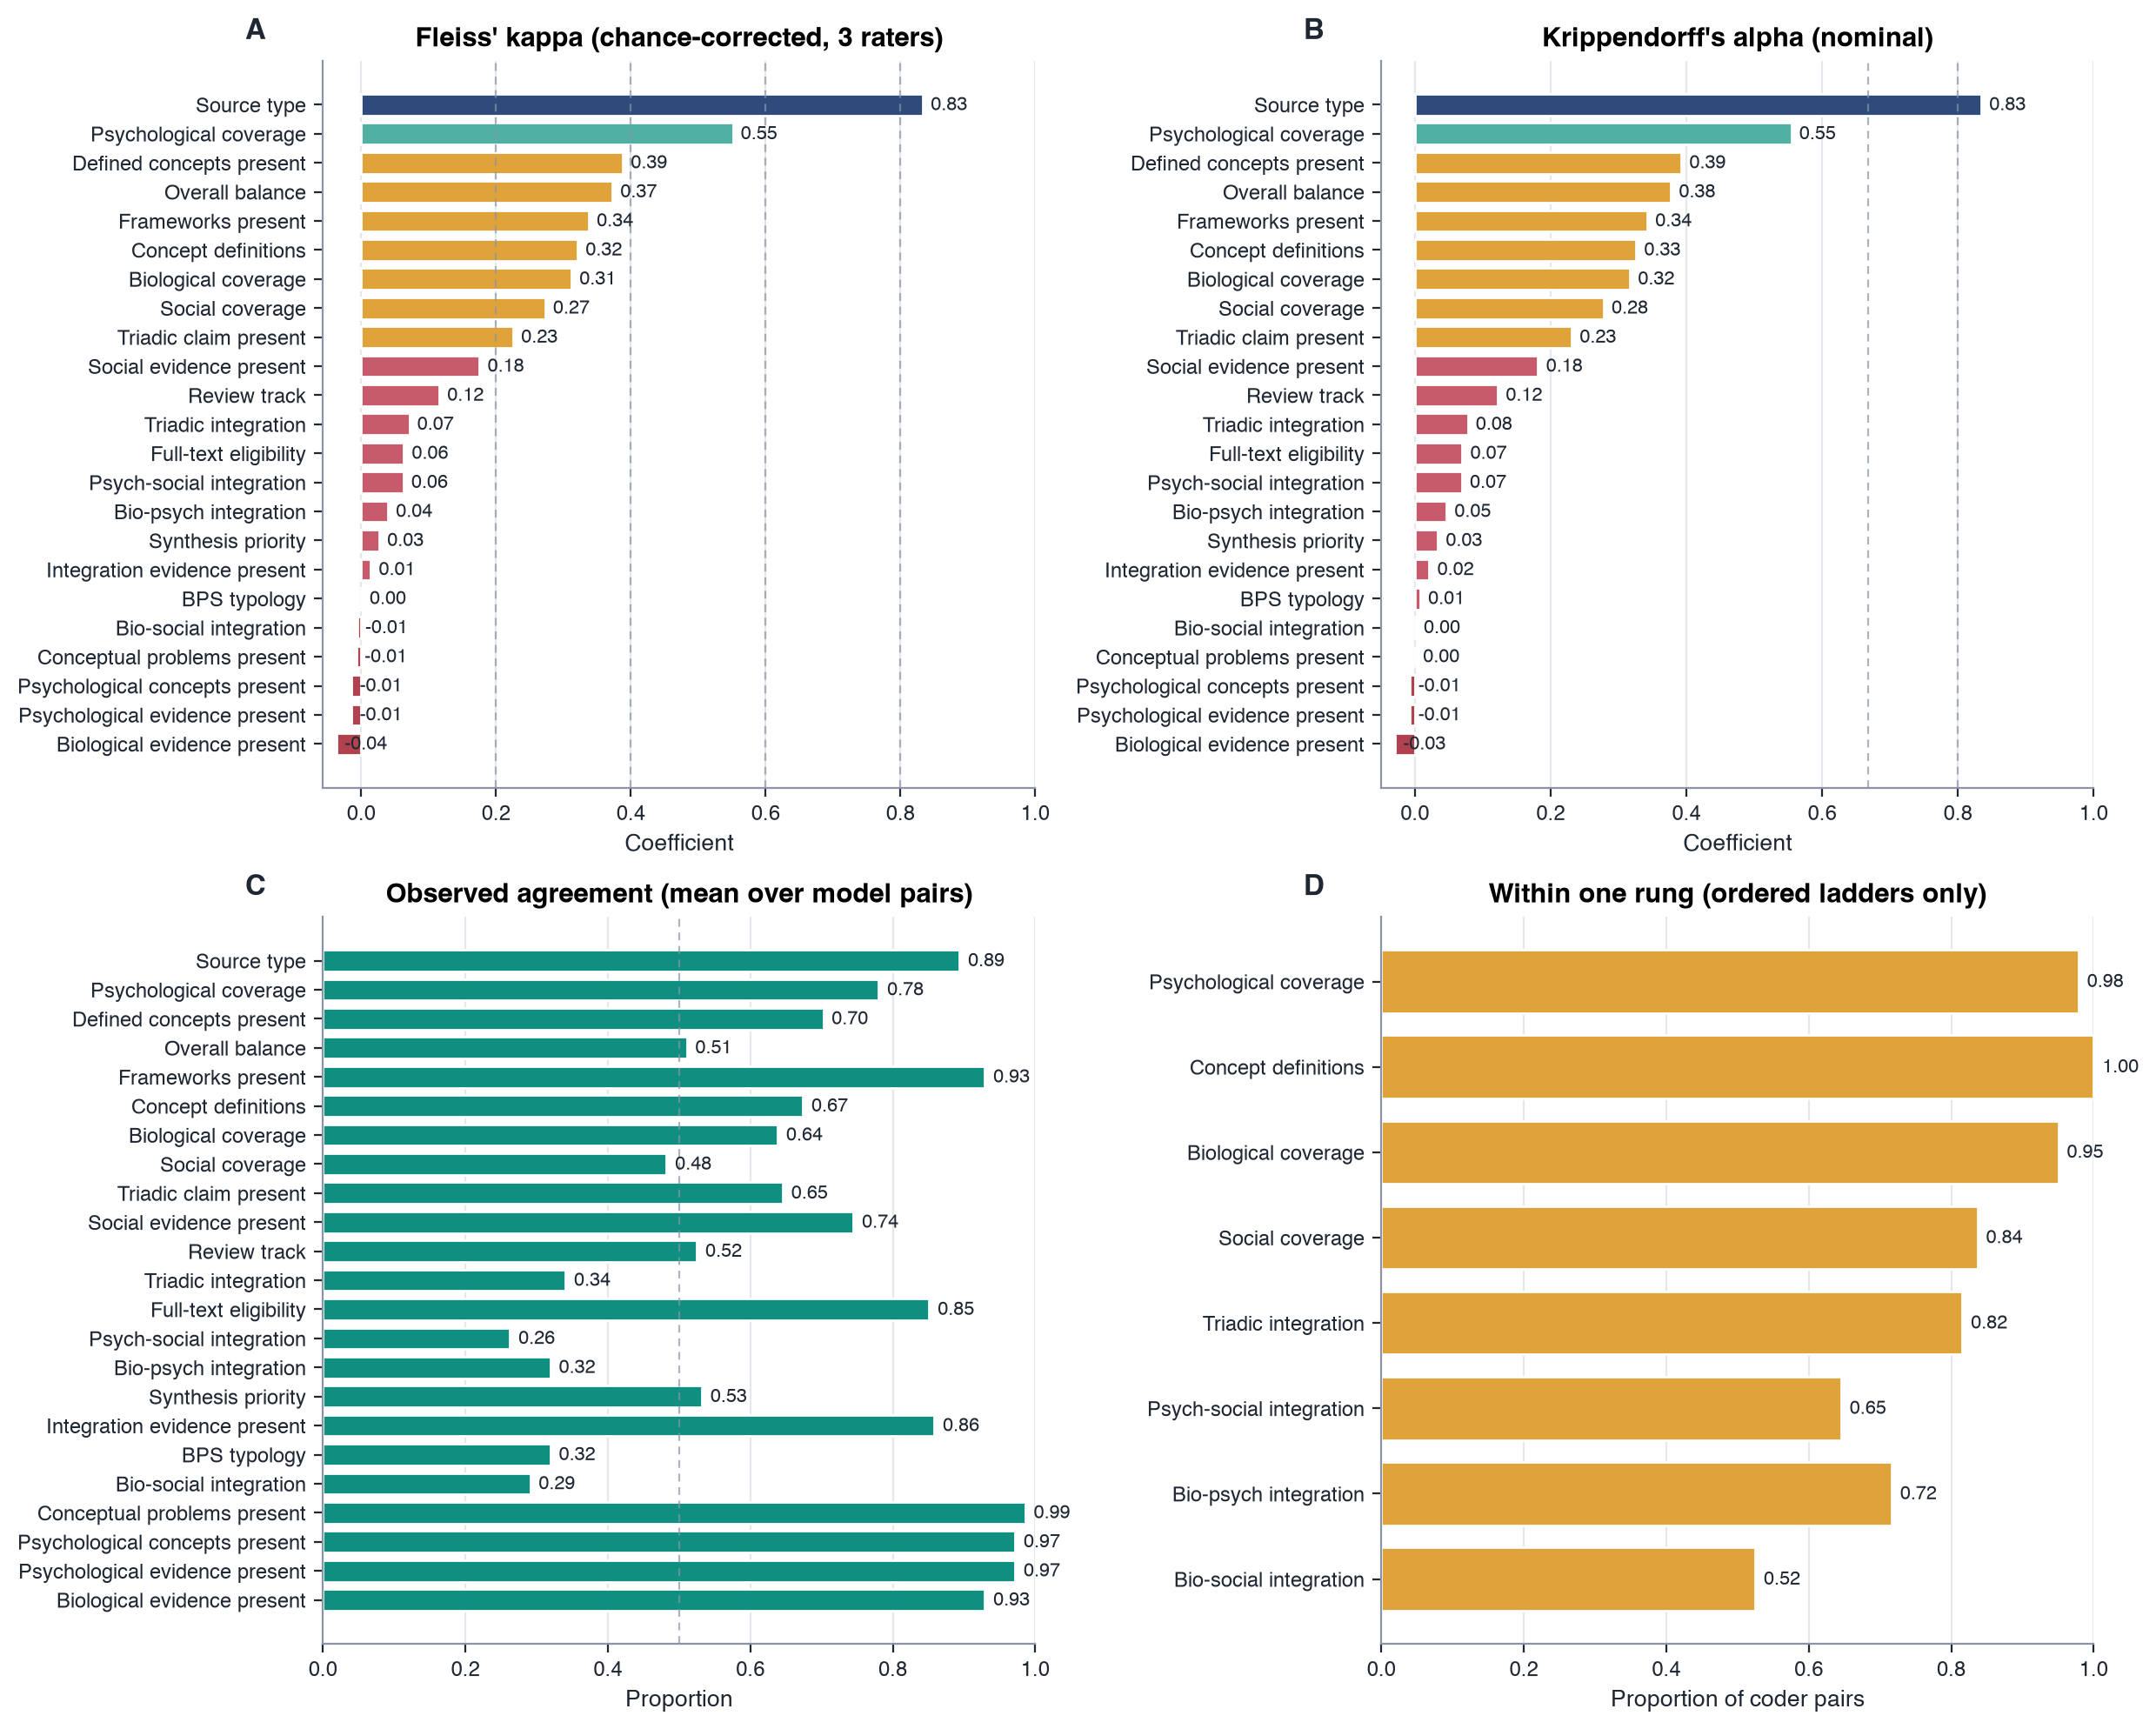

In [24]:
display(Image(filename=str(figures_dir() / "01_field_reliability_2x2.png")))

### Figure 2: agreement between providers, and the consensus typology

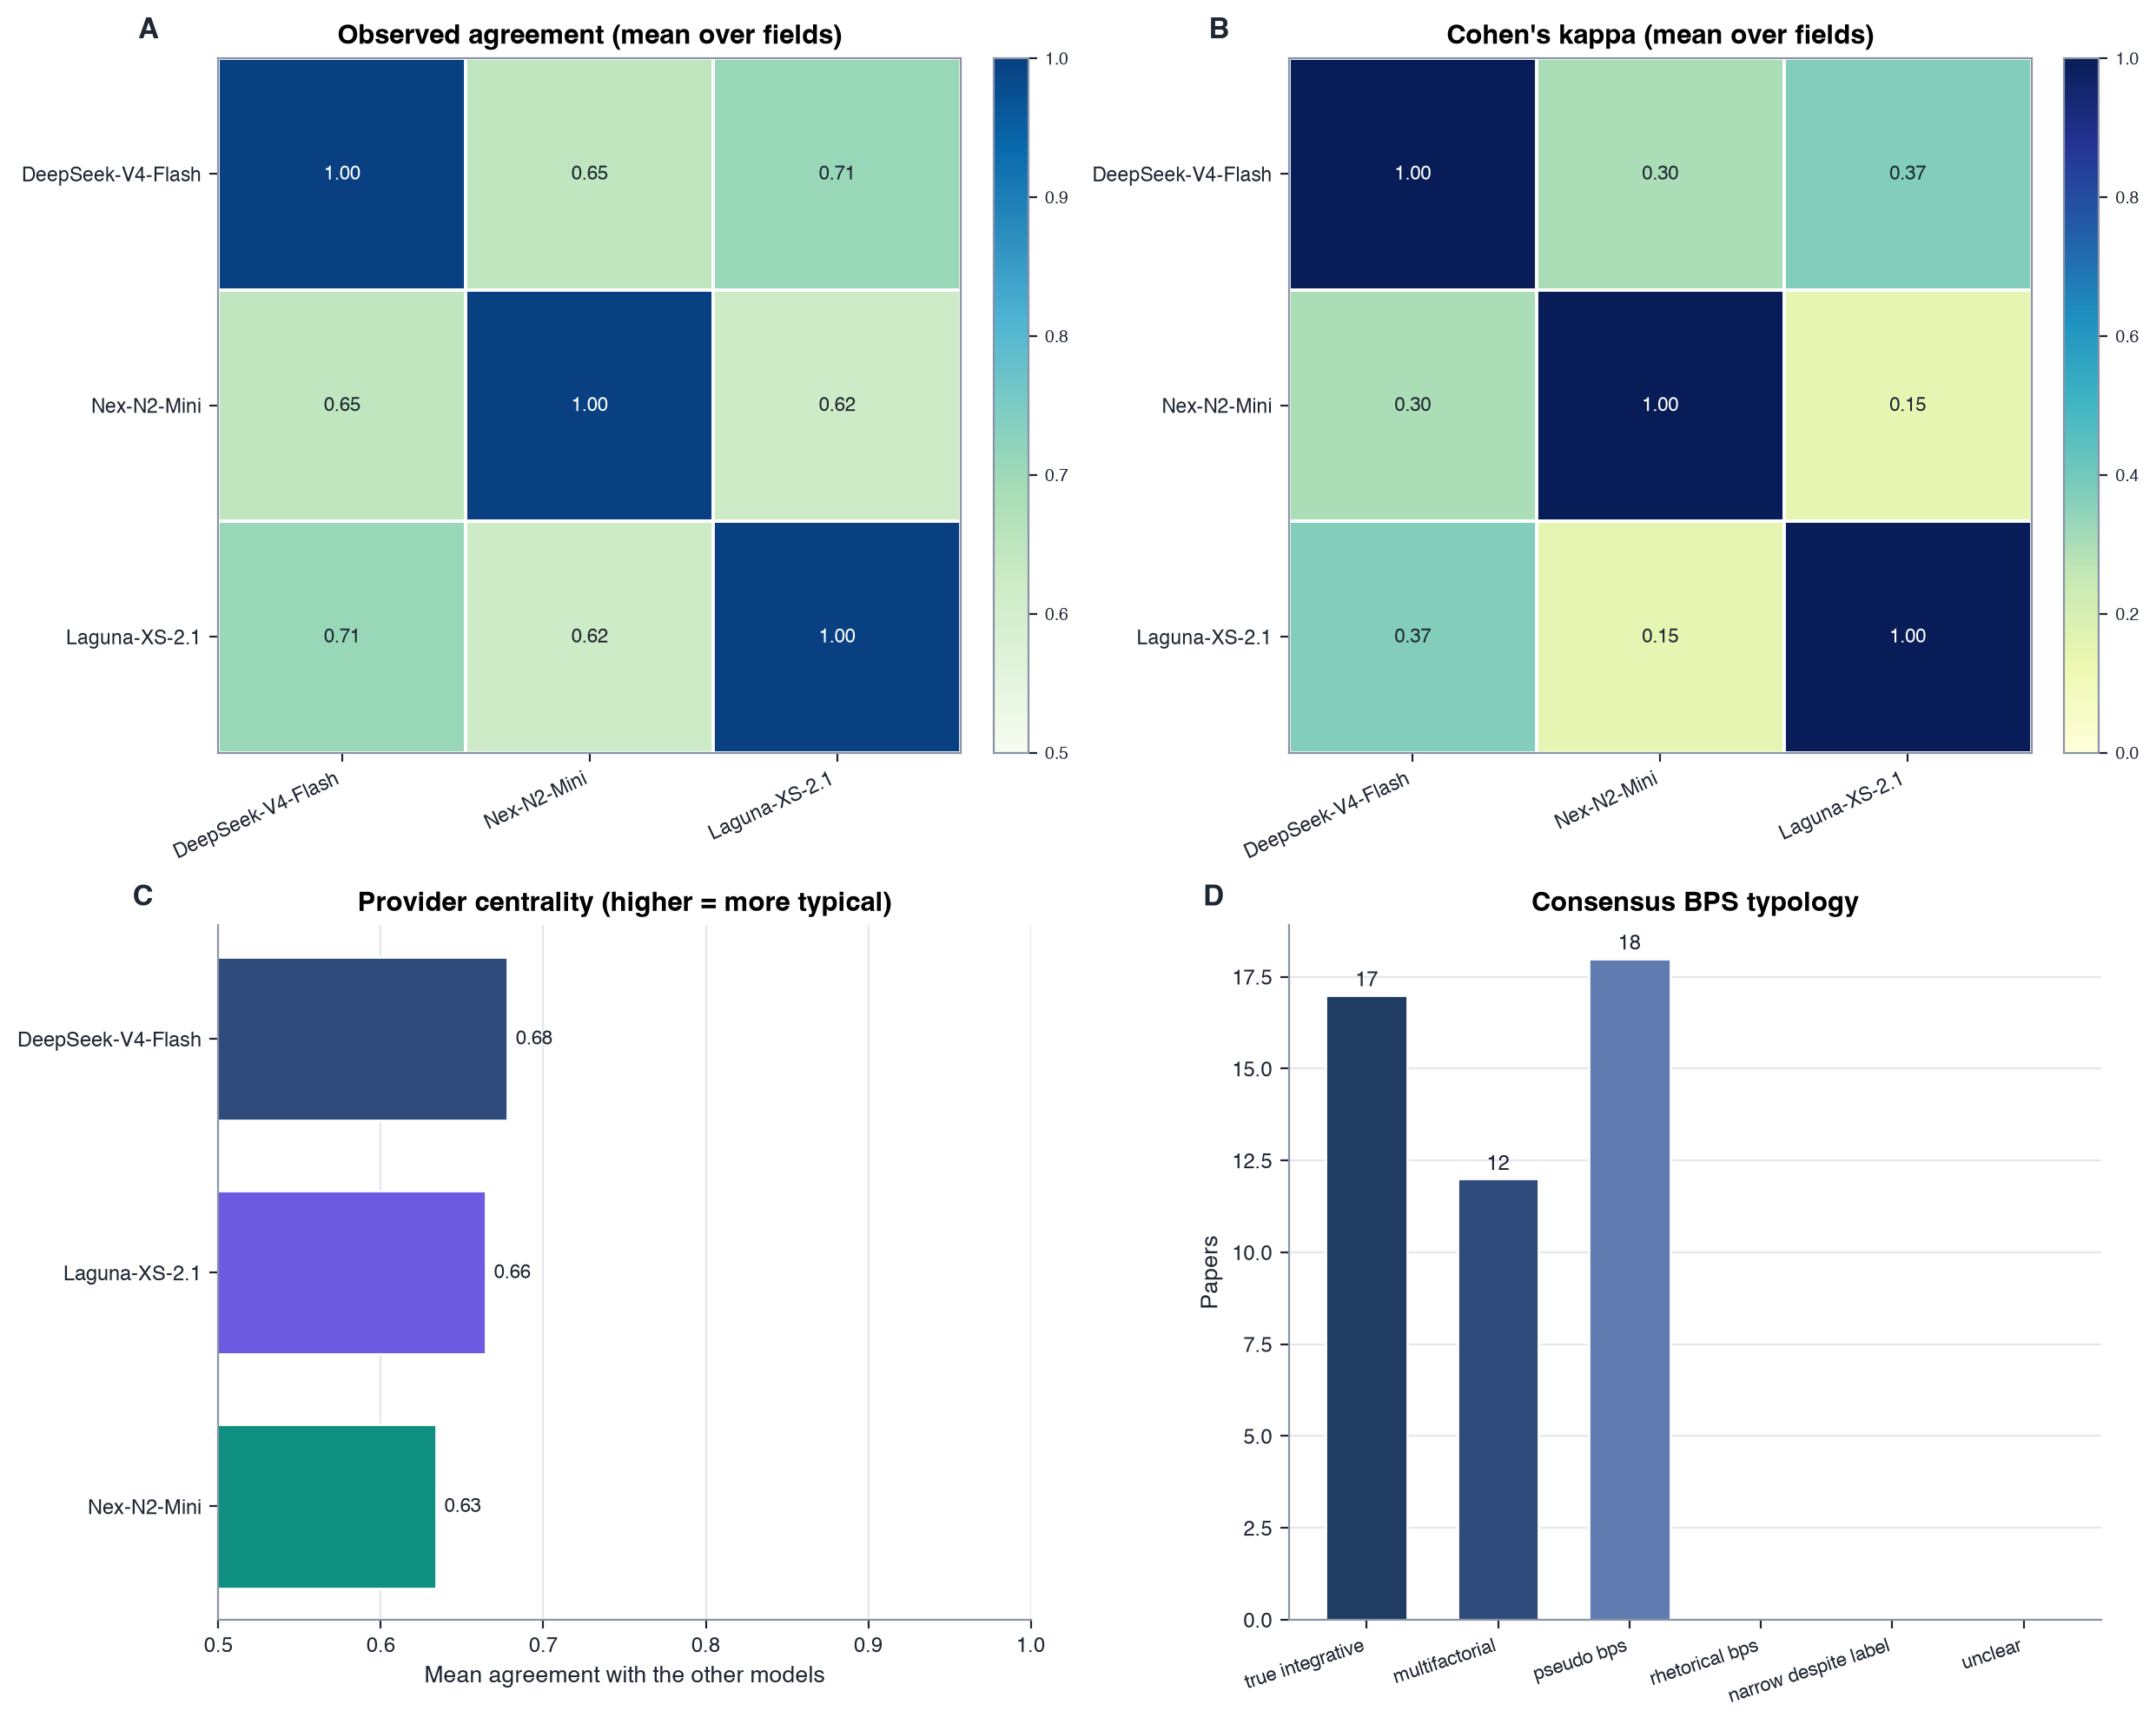

In [25]:
display(Image(filename=str(figures_dir() / "02_pairwise_and_consensus.png")))

### Figure 3: coverage and integration

Panels A and B are the corpus-level answer to the review's question, in consensus form: how
deeply each domain is covered, and how deeply each pair and the triad are integrated. Panel C
shows the same triadic judgement per model. Panel D is the integration index, one number per
coding, which makes the spread between the three readings visible.

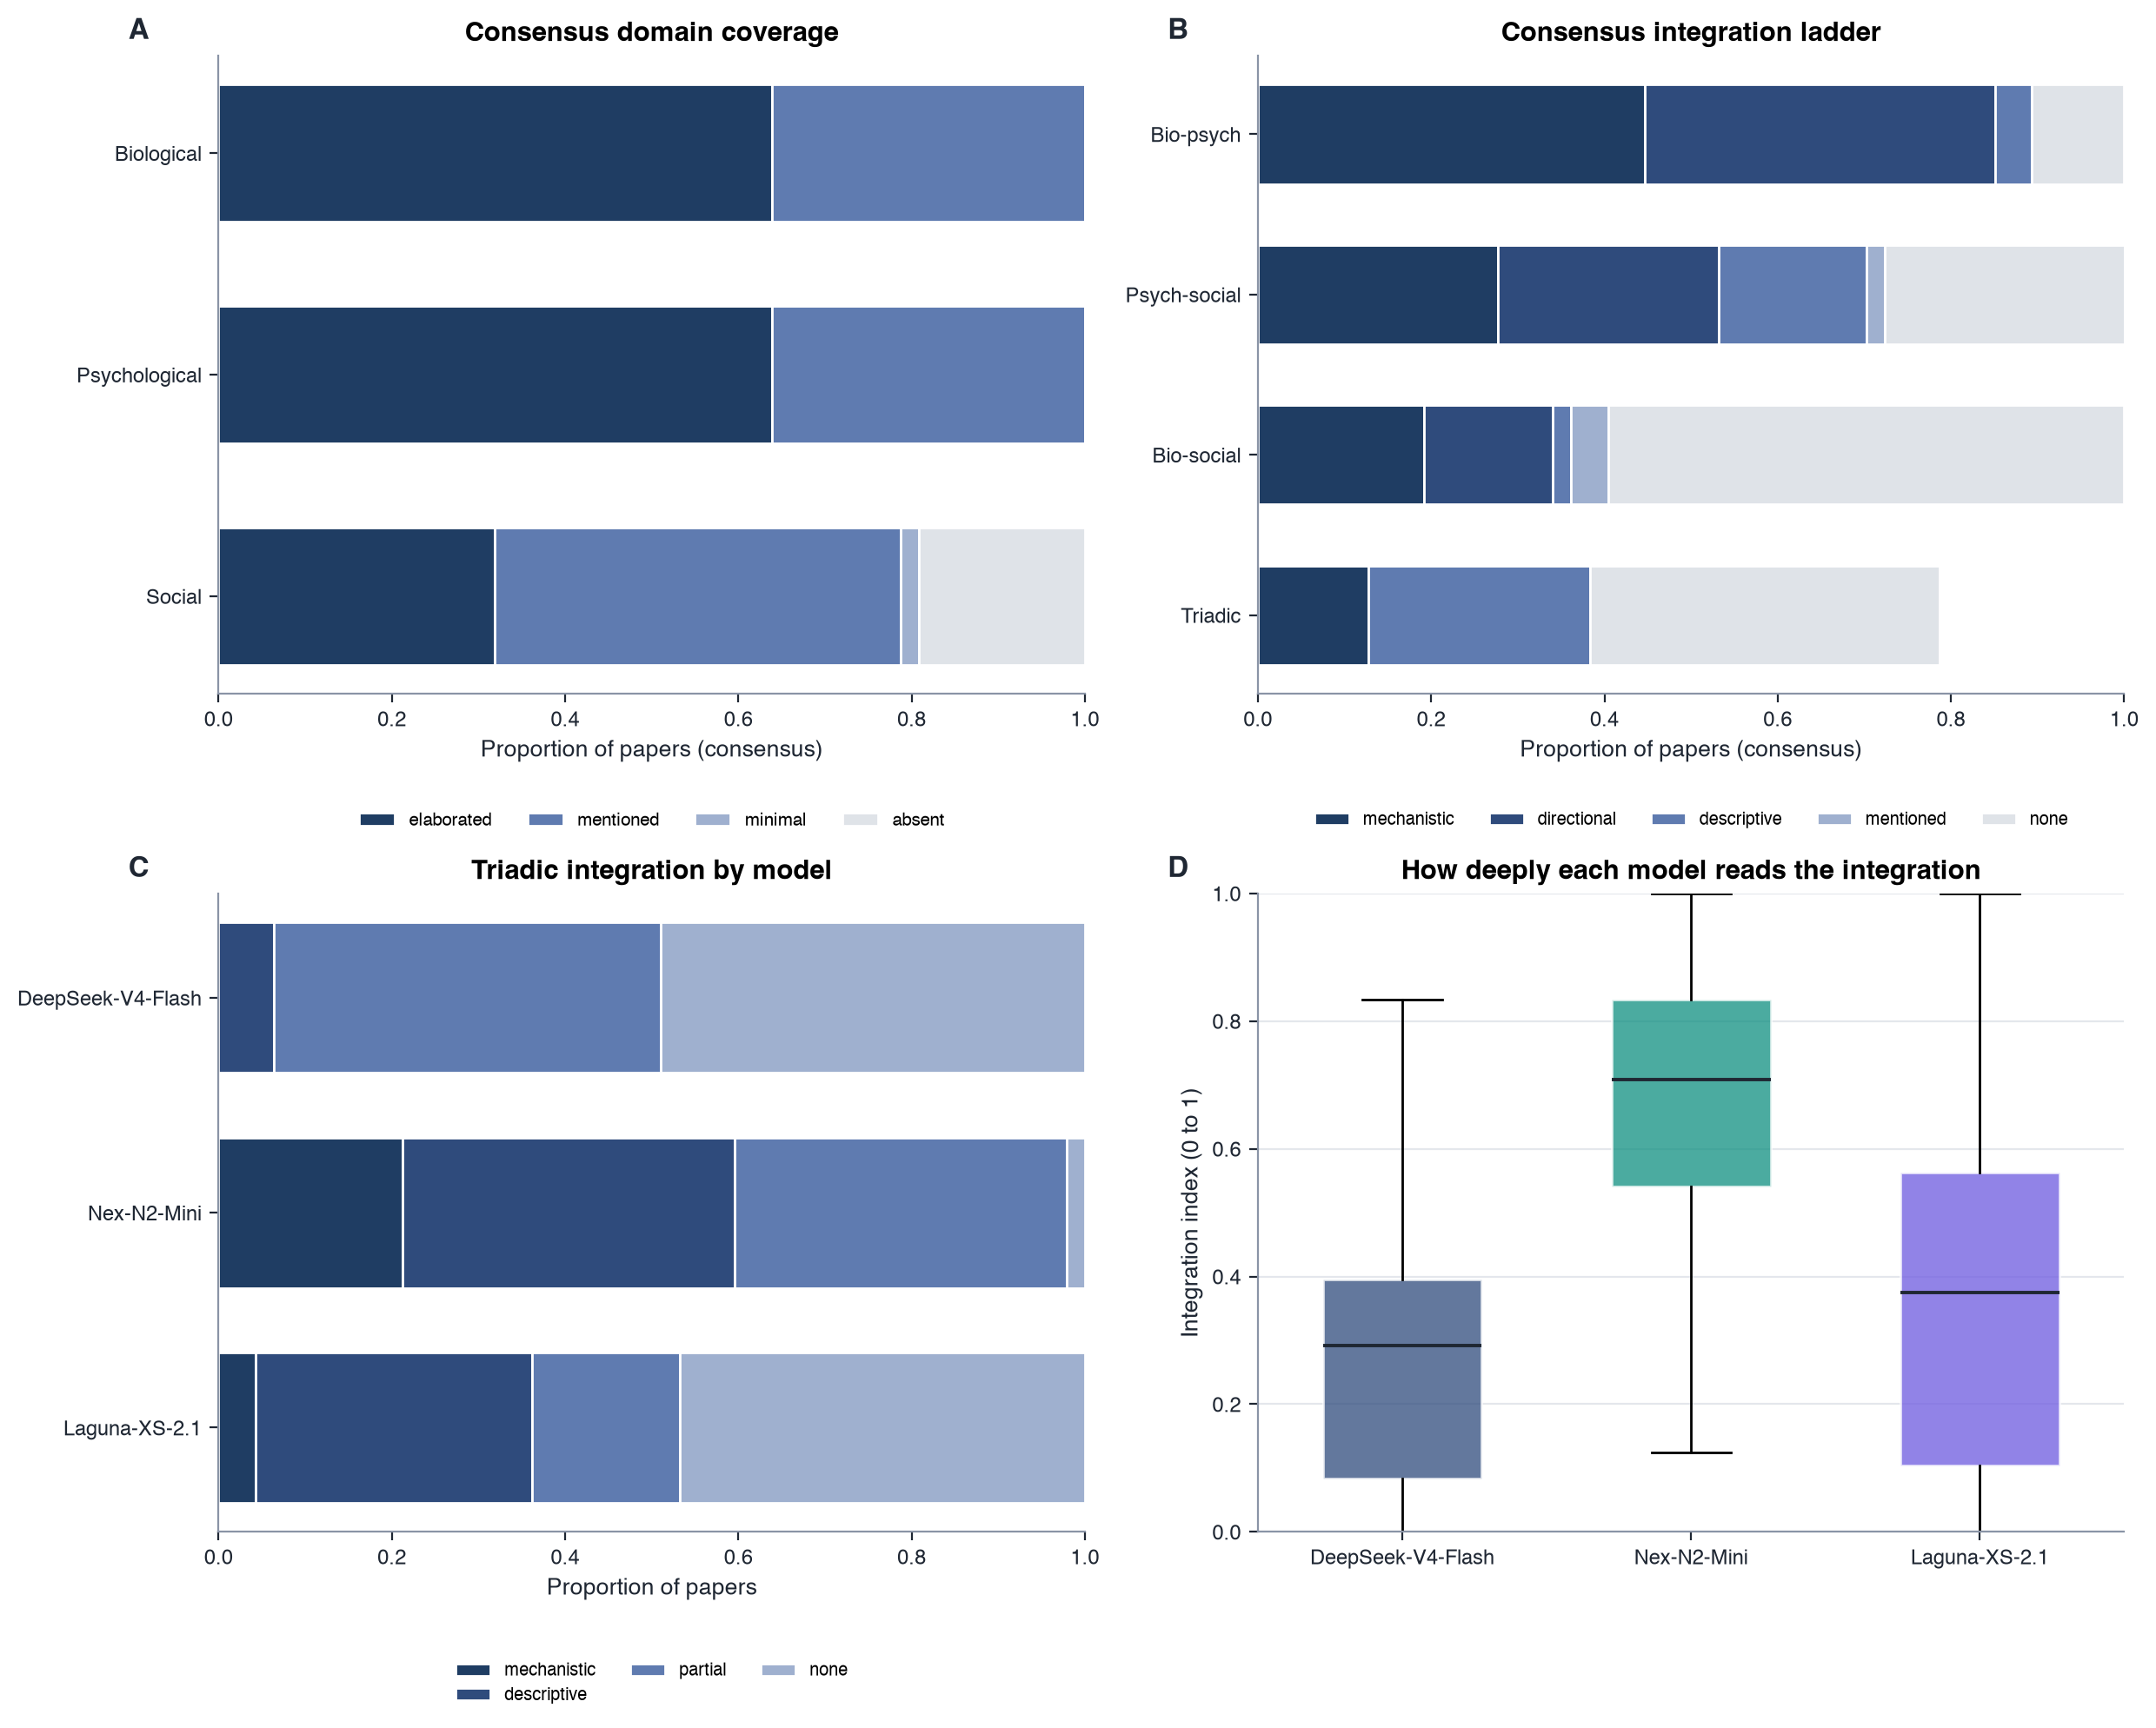

In [26]:
display(Image(filename=str(figures_dir() / "03_integration_profile.png")))

### Figure 4: evidence and yield

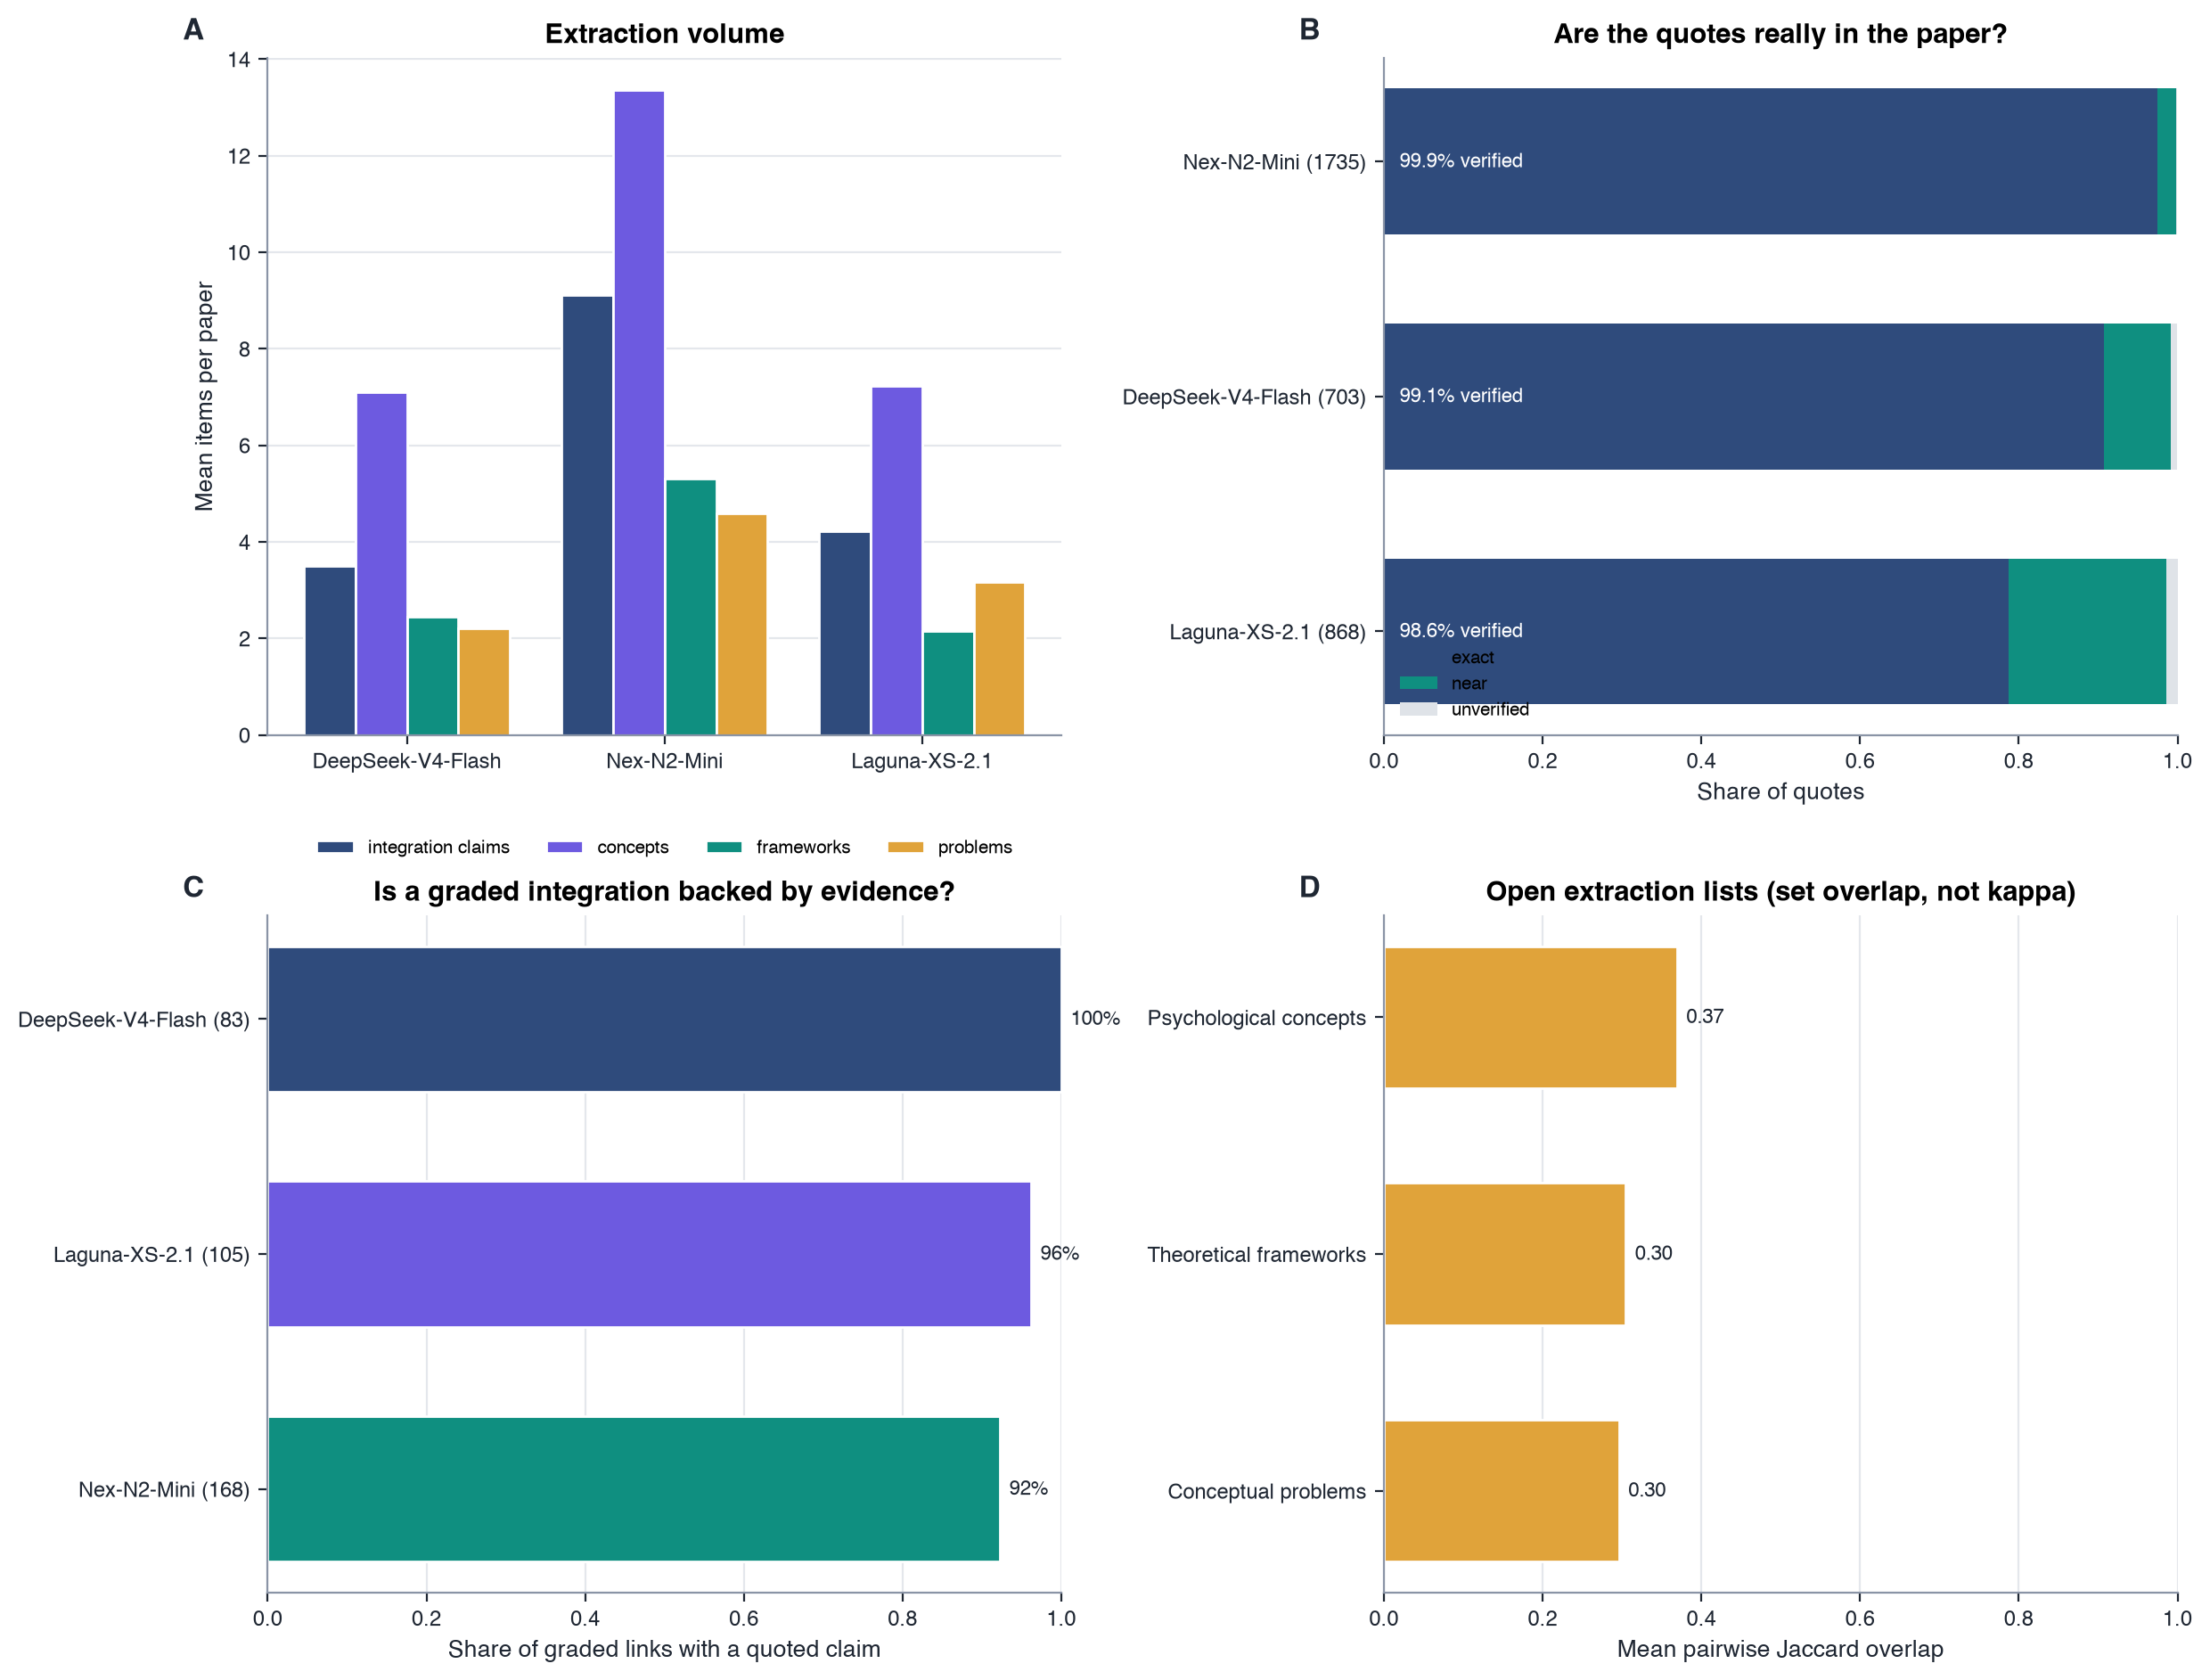

In [27]:
display(Image(filename=str(figures_dir() / "04_evidence_and_yield.png")))

## 8. The typology, checked against itself

`bps_typology` is the scheme's summary verdict, and it is the field the review's argument rests
on. It is also the hardest to specify, because it compresses coverage and integration into one
label.

So the pipeline computes it twice. The coder codes it as the codebook describes, and the
pipeline independently derives `derived_typology` from the coverage and integration values by a
fixed rule. Their concordance is a direct test of whether the typology definition is tight
enough to be applied the same way twice. Where they diverge, the codebook is under-specified,
not the coder.

In [28]:
print(f"Coded typology matches the rule-derived typology in "
      f"{summary['typology_coded_matches_derived']:.1%} of codings.")
print()
concordance = results["typology_concordance"]
pivot = concordance.pivot(index="bps_typology", columns="derived_typology", values="n_codings").fillna(0).astype(int)
pivot

Coded typology matches the rule-derived typology in 60.3% of codings.



derived_typology,multifactorial,narrow_despite_label,pseudo_bps,rhetorical_bps,true_integrative
bps_typology,,,,,
multifactorial,20,0,8,0,16
pseudo_bps,21,1,34,0,3
rhetorical_bps,1,3,3,2,0
true_integrative,0,0,0,0,29


In [29]:
per_model = (long_df.groupby("model_label")["typology_matches_derived"]
             .apply(lambda values: float((values == "yes").mean())).round(3))
print("Concordance between the coded and the derived typology, per model:")
print(per_model.to_string())

Concordance between the coded and the derived typology, per model:
model_label
DeepSeek-V4-Flash    0.702
Laguna-XS-2.1        0.489
Nex-N2-Mini          0.617


## 9. The consensus picture

What the corpus looks like once the three codings are collapsed by majority vote. These numbers
describe 47 open-access articles coded by three cheap models; they are a demonstration of what
the pipeline reports, not a result about the literature.

In [30]:
consensus = results["consensus"]
for field in list(COVERAGE_FIELDS) + list(INTEGRATION_FIELDS):
    counts = consensus[field].value_counts()
    line = ", ".join(f"{label} {count}" for label, count in counts.items())
    print(f"{FIELD_LABELS[field]:26s} {line}")
print()
print("BPS typology (consensus):")
print(consensus["bps_typology"].value_counts().to_string())
print()
print("Full-text eligibility (consensus):")
print(consensus["fulltext_eligibility"].value_counts().to_string())

Biological coverage        elaborated 30, mentioned 17
Psychological coverage     elaborated 30, mentioned 17
Social coverage            mentioned 22, elaborated 15, absent 9, minimal 1
Bio-psych integration      mechanistic 21, directional 19, none 5, descriptive 2
Psych-social integration   mechanistic 13, none 13, directional 12, descriptive 8, mentioned 1
Bio-social integration     none 28, mechanistic 9, directional 7, mentioned 2, descriptive 1
Triadic integration        none 19, descriptive 12, partial 10, mechanistic 6

BPS typology (consensus):
bps_typology
pseudo_bps          18
true_integrative    17
multifactorial      12

Full-text eligibility (consensus):
fulltext_eligibility
include    47


### What the corpus talks about

The most frequently extracted concepts and frameworks across all three coders. This is a look at
what the corpus contains, not a synthesis: the actual synthesis happens later, on the screened
corpus, with the finalized schemes.

In [31]:
label_catalog(items_df, "psychological_concepts", top_n=15)

,label_normalized,n_extractions,n_papers,n_models
36,anxiety,95,37,3
129,depression,78,31,3
69,catastrophizing,46,22,3
320,pain catastrophizing,43,16,3
437,self-efficacy,39,16,3
236,kinesiophobia,29,10,3
190,fear-avoidance,15,10,3
465,stress,15,10,3
114,coping,13,8,3
119,coping strategies,13,7,3


In [32]:
label_catalog(items_df, "theoretical_frameworks", top_n=12)

,label_normalized,n_extractions,n_papers,n_models
30,biopsychosocial model,61,28,3
99,fear-avoidance model,18,8,3
36,biopsychosocial model of pain,10,4,3
28,biopsychosocial framework,4,4,1
60,cognitive behavioral therapy (cbt),4,4,1
20,biomedical model,6,3,3
53,central sensitization,4,3,3
23,biopsychosocial approach,5,2,3
111,gate control theory of pain,4,2,3
163,minority stress model,4,2,3


## 10. Cost, outputs, and takeaways

In [33]:
run_manifest = json.loads((codings_dir() / "run_manifest.json").read_text())
usage = run_manifest["token_usage_total"]
print(f"Papers x models : {run_manifest['n_papers']} x {run_manifest['n_models']} = {run_manifest['n_codings']} codings")
print(f"Extracted items : {run_manifest['n_extracted_items']:,}")
print(f"Tokens          : {usage['total_tokens']:,} (of which {usage['reasoning_tokens']:,} reasoning)")
print(f"Cost            : ${usage['cost_usd']:.3f}")
print()
for label, values in run_manifest["token_usage_by_model"].items():
    print(f"  {label:20s} {values['total_tokens']:>10,} tokens   ${values['cost_usd']:.4f}")

Papers x models : 47 x 3 = 141 codings
Extracted items : 4,080
Tokens          : 3,155,248 (of which 931,058 reasoning)
Cost            : $0.264

  Laguna-XS-2.1           753,188 tokens   $0.0482
  DeepSeek-V4-Flash       689,026 tokens   $0.0900
  Nex-N2-Mini           1,713,034 tokens   $0.1256


In [34]:
summary_text = write_fulltext_summary(long_df, results, integrity, corpus)
base = ROOT / "src" / "05_data" / "pilot" / "02_fulltext_level"
for path in sorted(base.rglob("*")):
    if path.is_file() and path.suffix in {".csv", ".json", ".png", ".md", ".log"}:
        print(path.relative_to(base))

01_corpus/01_retrieval_candidates.csv
01_corpus/02_fulltext_corpus.csv
01_corpus/04_retrieval_log.csv
01_corpus/05_corpus_manifest.json
02_model_codings/all_extracted_items_long.csv
02_model_codings/all_model_codings_long.csv
02_model_codings/by_model/01_deepseek_v4_flash.csv
02_model_codings/by_model/01_deepseek_v4_flash_items.csv
02_model_codings/by_model/02_nex_n2_mini.csv
02_model_codings/by_model/02_nex_n2_mini_items.csv
02_model_codings/by_model/03_laguna_xs_2_1.csv
02_model_codings/by_model/03_laguna_xs_2_1_items.csv
02_model_codings/run.log
02_model_codings/run_manifest.json
03_reliability/01_field_reliability.csv
03_reliability/02_pairwise_percent_agreement.csv
03_reliability/03_pairwise_cohen_kappa.csv
03_reliability/04_per_model_behavior.csv
03_reliability/05_consensus_codings.csv
03_reliability/06_eligibility_depth_distribution.csv
03_reliability/07_list_overlap.csv
03_reliability/08_typology_concordance.csv
03_reliability/09_extraction_yield.csv
03_reliability/10_quote_ver

### Takeaways

1. **The chain runs end to end.** A PubMed query, 100 abstracts coded by three providers, a
   consensus filter, open-access retrieval, and full-text coding of every retrieved paper by the
   same three providers, with no failed codings and for a cost measured in cents.

2. **Read the integrity numbers before the agreement numbers.** Quote verification and the
   evidence-discipline check answer a prior question: did the coder read the paper, and does its
   graded ladder point at a passage. Agreement between coders who are not reading the text would
   be worthless, however high.

3. **The integration ladder is where the scheme needs the most work.** Chance-corrected
   agreement on the four integration fields is close to zero while adjacent agreement is much
   higher: the coders land next to each other on the ladder rather than on it. Reading the two
   numbers together is what makes that diagnosable, and it points straight at the boundary
   rules between `mechanistic`, `directional`, and `descriptive`.

4. **The typology is where the scheme is loosest.** Both the between-coder agreement on
   `bps_typology` and its concordance with the rule-derived typology point at the same place:
   the value definitions compress too much into one label. That is the most actionable thing
   this run has to say to the expert evaluation.

5. **Extraction volume is not extraction quality.** The model that extracts the most items is
   not automatically the one whose quotes verify best. Both numbers are reported per model, and
   both belong in the choice of the state-of-the-art model for the real run.

**To reproduce**

```bash
python -m bps_review run-abstract-testrun --force-corpus --force-coding   # notebook 01
python -m bps_review build-fulltext-corpus                                # retrieval
python -m bps_review run-fulltext-testrun --force-coding                  # this notebook
```

The models are configured in `src/03_pipeline/bps_review/pilot/config.py` and reused here;
replacing them with state-of-the-art models is a single edit to `TESTRUN_MODELS`.